In [ ]:
#r "FreeXNSE.dll"
#r "BoSSSpad.dll"
using System;
using System.Data;
using System.Collections.Generic;
using System.Linq;
using System.IO;
using ilPSP;
using ilPSP.Utils;
using BoSSS.Platform;
using BoSSS.Foundation;
using BoSSS.Foundation.XDG;
using BoSSS.Foundation.Grid;
using BoSSS.Foundation.Grid.Classic;
using BoSSS.Foundation.IO;
using BoSSS.Solution;
using BoSSS.Solution.Control;
using BoSSS.Solution.GridImport;
using BoSSS.Solution.Statistic;
using BoSSS.Solution.Utils;
using BoSSS.Solution.AdvancedSolvers;
using BoSSS.Solution.Gnuplot;
using BoSSS.Application.BoSSSpad;
using FreeXNSE;
using static BoSSS.Application.BoSSSpad.BoSSSshell;
using System.Diagnostics;
using Microsoft.AspNetCore.Html;
using System.Text.RegularExpressions;

Init();

In [ ]:
string proj = "ContactAngleHysteresis";
BoSSSshell.WorkflowMgm.Init(proj);
BoSSSshell.WorkflowMgm.SetNameBasedSessionJobControlCorrelation();


In [ ]:
//BoSSSshell.WorkflowMgm.ResetProject(true, true, true, true);

Utility routines to create the control objects.  
Basically a base configuration and easy to use wrapper routines to configure e.g. the hysteresis values for the contact angle  

In [ ]:
static GridCommons ContactAngleHysteresisGrid(int GridRes, double R){
    var _xNodes = GenericBlas.Linspace(0, 2.2*R, GridRes + 1);
    var _yNodes = GenericBlas.Linspace(-2.2*R, 2.2*R, 2 * GridRes + 1);

    var grd = Grid2D.Cartesian2DGrid(_xNodes, _yNodes, BoSSS.Foundation.Grid.RefElements.CellType.Square_Linear);

    grd.DefineEdgeTags(delegate (double[] _X) {
        double x = _X[0];
        double y = _X[1];
        if(Math.Abs(y - _yNodes.First()) < 1.0e-12)
            // bottom
            return "Neumann_bottom";
        if(Math.Abs(y - _yNodes.Last()) < 1.0e-12)
            // top
            return "Neumann_top";
        if(Math.Abs(x - _xNodes.First()) < 1.0e-12)
            // left
            return "Robin_left";
        if(Math.Abs(x - _xNodes.Last()) < 1.0e-12)
            // right
            return "Neumann_right";

        throw new ArgumentOutOfRangeException();
    });
    
    grd.Name = "ContactAngleHysteresisMesh_" + GridRes;
    BoSSSshell.WorkflowMgm.DefaultDatabase.SaveGrid(ref grd);
    
    return grd;    
}

static FreeXNSE_Control ContactAngleHysteresis_Base(int GridRes, int level, int k){
   FreeXNSE_Control C = new FreeXNSE_Control(true);
    
    C.savetodb = true;
    C.ProjectName = "ContactAngleHysteresis";
    
    // Solver Options
    C.TimesteppingMode = AppControl._TimesteppingMode.Transient;
    C.TimeSteppingScheme = BoSSS.Solution.XdgTimestepping.TimeSteppingScheme.ImplicitEuler;
    C.LSContiProjectionMethod = BoSSS.Solution.LevelSetTools.ContinuityProjectionOption.ConstrainedDG;
    C.Option_LevelSetEvolution = BoSSS.Solution.LevelSetTools.LevelSetEvolution.StokesExtension;
    
    C.ActiveTerms.Viscous = Viscous.SIP;
    C.ActiveTerms.Convective = Convective.Off;
    C.ActiveTerms.Temporal = Temporal.Off;
    
    // degree
    C.SetDGdegree(k);
    
    // Create Grid
    double R = 1;
    C.SetGrid(ContactAngleHysteresisGrid(GridRes,R));
    
    C.AddInitialValue("Phi", $"X => Math.Sqrt(Math.Pow(X[0], 2) + Math.Pow(X[1],2)) - {R}", false);
    
    C.DimensionlessNumbers.Fr = Math.PI/2.0*R*R;
    C.VolumeForce = new ConstantGravity(new double[] { 0.0, -1.0 });
    C.ActiveTerms.SurfaceTension = SurfaceTension.LaplaceBeltrami;
    C.FixedInterface = false;
    
    C.dtFixed = 0.01;
    C.NoOfTimesteps = 500;
    
    C.AdaptiveMeshRefinement = level > 0;
    C.AMR_startUpSweeps = level;
    C.activeAMRlevelIndicators.Add(new BoSSS.Solution.LevelSetTools.SolverWithLevelSetUpdater.AMRonNarrowband() { maxRefinementLevel = level });
    
    C.PostprocessingModules.Add(new ContactLineLogging());
    
    C.SessionName =  "DropletContactAngleHysteresis";
    
    return C;
}

static void SetBoundarySlip(this FreeXNSE_Control C, double SlipScaling, double SlipConstant){
    C.SlipScaling = SlipScaling;
    C.DimensionlessNumbers.beta = SlipConstant;

    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("SlipScaling", SlipScaling.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("SlipConstant", SlipConstant.ToString("N4")));

    C.SessionName = C.SessionName + "_BndySlip"  + SlipConstant.ToString("N1") + "_" + SlipScaling.ToString("N1");
}

static void SetContactLineSlip(this FreeXNSE_Control C, double SlipExponent, double SlipConstant){
    C.ContactAngleScaling = SlipExponent;
    C.DimensionlessNumbers.alpha = SlipConstant;
    
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("LineSlipExponent", SlipExponent.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("LineSlipConstant", SlipConstant.ToString("N4")));

    C.SessionName = C.SessionName + "_LineSlip"  + SlipConstant.ToString("N1") + "_" + SlipExponent.ToString("N1");
}

static void SetViscosity(this FreeXNSE_Control C, double ViscosityScaling, double ViscosityConstant){
    C.ViscosityScaling = ViscosityScaling;
    C.DimensionlessNumbers.Oh = ViscosityConstant;

    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("ViscosityScaling", ViscosityScaling.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("ViscosityConstant", ViscosityConstant.ToString("N4")));
    
    C.SessionName = C.SessionName + "_Visc"  + ViscosityConstant.ToString("N1") + "_" + ViscosityScaling.ToString("N1");
}

static void SetContactAngle(this FreeXNSE_Control C, double Theta, double ThetaAdv = 0.0, double ThetaRec = Math.PI){
    C.DimensionlessNumbers.Theta = Theta;
    C.DimensionlessNumbers.ThetaAdv = ThetaAdv;
    C.DimensionlessNumbers.ThetaRec = ThetaRec;

    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("theta0", Theta.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("thetaAdv", ThetaAdv.ToString("N4")));
    C.Paramstudy_CaseIdentification.Add(new Tuple<string, object>("thetaRec", ThetaRec.ToString("N4")));

    C.SessionName = C.SessionName + "_CAeq" + Theta.ToString("N4") + (ThetaAdv != 0.0 ? "_CAa" + ThetaAdv.ToString("N4") : "") + (ThetaRec != Math.PI ? "_CAr" + ThetaRec.ToString("N4") : "");
}


In [ ]:
int[] degS = new int[] { 4 };
int[] GridResS = new int[] { 3 };

In this testcase a droplet is placed on a vertical wall under the influence of gravity.  
This allows us to predict the final values the contact angles (given a specific advancing or receding pinning value) will finally obtain:  
$$
\cos(\theta_{adv})-\cos(\theta_{rec}) = -\frac{\pi R^2 We}{2 Fr}
$$
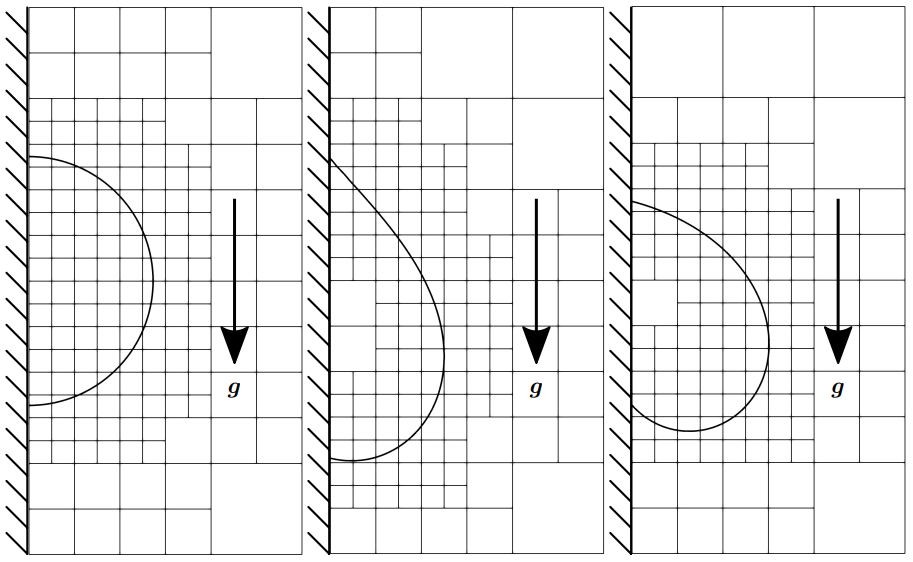

In [ ]:
// Testcase setup - First series
// ==============
List<FreeXNSE_Control> controls = new List<FreeXNSE_Control>();
double Theta = Math.PI/2.0;

double[] slipconstS = new double[] {0.0, 1.0, double.PositiveInfinity}; // freeslip, constzant slip, no-slip
double[] slipscalingS = new double[] {0.0}; // just a constant value
double[] clslipscalingS = new double[] {0.5, 1.0, 2.0};
double[] clslipconstS = new double[] {0.0,  0.5};

foreach(int deg in degS){
foreach(int GridRes in GridResS){

foreach(double slipconst in slipconstS){
foreach(double slipscaling in slipscalingS){
foreach(double clslipconst in clslipconstS){
foreach(double clslipscaling in clslipscalingS){
    if(!(clslipconst == 0.0 && clslipscaling != 1.0)){
        var C = ContactAngleHysteresis_Base(GridRes, 2, deg);
        C.SetBoundarySlip(slipscaling, slipconst);
        C.SetContactLineSlip(clslipscaling, clslipconst);
        C.SetViscosity(0.0, 1.0); // constant viscosity
        C.SetContactAngle(Math.PI/2.0, Math.PI/2.0 + Math.PI/12.0, 0.0);
        controls.Add(C);
    }

     if(!(clslipconst == 0.0 && clslipscaling != 1.0)){
        var C = ContactAngleHysteresis_Base(GridRes, 2, deg);
        C.SetBoundarySlip(slipscaling, slipconst);
        C.SetContactLineSlip(clslipscaling, clslipconst);
        C.SetViscosity(0.0, 1.0); // constant viscosity
        C.SetContactAngle(Math.PI/2.0, Math.PI, Math.PI/2.0 - Math.PI/12.0);
        controls.Add(C);
    }
}
}
}
}

}
}
controls.ForEach(c => c.SessionName.Display());

In [ ]:
int ctrlCount = controls.Count();

In [ ]:
bool run      = true;
var bpc = BoSSSshell.GetDefaultQueue();

In [ ]:
//BoSSSshell.WorkflowMgm.ResetProject();

In [ ]:
// if(BoSSSshell.WorkflowMgm.AllJobs.Count() > 0){
//      BoSSSshell.WorkflowMgm.ResetProject();
// }
var jobs = controls.Select(c => c.CreateJob()).ToArray();
jobs.ForEach(j => j.NumberOfThreads = 1);
jobs.ForEach(j => j.EnvironmentVars["BOSSS_ARG_7"] = j.NumberOfThreads.ToString());
jobs.Activate();

In [ ]:
var sessions = BoSSSshell.wmg.Sessions;
sessions

In [ ]:
//sessions.ForEach(s => s.Export().To(Path.GetFullPath(Path.Combine(s.ProjectName, s.Name))).WithSupersampling(3).WithShadowFields().Do())

Wait to finish and check for succesful termination

In [ ]:
BoSSSshell.WorkflowMgm.BlockUntilAllJobsTerminate(54000);

In [ ]:
int count = BoSSSshell.wmg.Sessions.Count();
int success = BoSSSshell.wmg.Sessions.Where(s => s.SuccessfulTermination).Count();

if(count != ctrlCount || count != success){
    throw new ApplicationException("Not all simulations calculated or finished successful!");
}